<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Earth Diagnostic 2 - Matter Evolution and Regeneration Probabilities
---

This notebook continues the Earth diagnostic series. It covers the two modules
built on top of the density and geometry primitives from
`diagnostic1_earth_density.ipynb`: `earth_evolutor`
(`tpeanuts.medium.earth.evolutor`), which builds the full flavour-basis Earth
evolution operator, and `earth_probability_state` (`tpeanuts.medium.earth.probability`), which
turns that operator into final flavour probabilities for both the analytical
and numerical propagation methods.

The notebook is intentionally diagnostic rather than a pytest suite. The
automated sanity checks live in `tpeanuts.medium.earth.test.test3_evolutor` and
`tpeanuts.medium.earth.test.test4_probabilities`; here we keep the plots and
physical interpretation. This notebook replaces and corrects the plots from the
historical backup scripts `tests_backup/4_earth/test3_evolutor.py`,
`test6_probabilities.py`, and `test6b_prob_compare.py`: in particular, the
transition-matrix plot in Section 5 now shows the physically meaningful
$|U_{\alpha\beta}|^2$ probability matrix (each row summing to 1 by unitarity)
instead of the ad hoc row-renormalized $|U_{\alpha\beta}|$ amplitude matrix used
in the old script.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: evolution operator, unitarity, earth_probability_state conventions, analytical vs numerical |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Unitarity-of-the-Evolution-Operator) | **Unitarity of the Evolution Operator**: raw vs reunitarized |
| [4](#4.-Distance-from-Identity-across-Energy-and-Nadir-Angle) | **Distance from Identity**: $\|U-I\|_F$ over $(E,\eta)$ |
| [5](#5.-Transition-Probability-Matrix-Structure) | **Transition Probability Matrix Structure**: Case A vs Case B, $|U_{\alpha\beta}|^2$ |
| [6](#6.-Regeneration-Probabilities-for-Pure-Mass-States) | **Regeneration Probabilities for Pure Mass States** vs nadir angle |
| [7](#7.-Electron-Flavour-Probability-Map) | **Electron-Flavour Probability Map**: $P_e(E,\eta)$ |
| [8](#8.-Mass-Basis-versus-Flavour-Basis-Input) | **Mass-Basis versus Flavour-Basis Input** comparison |
| [9](#9.-Analytical-versus-Numerical-Agreement) | **Analytical versus Numerical Agreement**: bars and error vs $\eta$ |
| [10](#10.-Numerical-Path-Evolution) | **Numerical Path Evolution** against the analytical final reference |
| [11](#11.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 From Segments to a Flavour-Basis Evolution Operator

`earth_evolutor` assembles the full $3\times3$ flavour-basis evolution operator
$U(E,\eta)$ for a trajectory with nadir angle $\eta$ and energy $E$. Internally it:

1. Classifies $\eta$ into the above-horizon, Case A (shell-crossing), and
   Case B (shallow) regimes of `diagnostic1_earth_density.ipynb`, Section 0.7.
2. For Case A, builds one reduced matter-segment evolutor per crossed shell
   (`evolutor_perturbative_segment`), composes them along the half-chord, and
   mirrors the result to the full chord.
3. For Case B, builds a single reduced evolutor for the constant-density
   midpoint segment.
4. Dresses the reduced (mass-kinetic) evolution operator into the full flavour
   basis via `pmns.flavour_basis`.
5. Optionally projects the result onto the nearest unitary matrix
   (`reunitarize=True`), absorbing small numerical drift from the perturbative
   expansion.

Above-horizon trajectories never touch Earth matter, so $U=\mathbb{1}$ exactly.

---

### 0.2 Unitarity as a Diagnostic

Because the perturbative segment evolutor is a truncated expansion, $U^\dagger U$
is unitary only up to the expansion's truncation order. The quantity

$$
\varepsilon_U = \max\bigl|\,U^\dagger U - \mathbb{1}\,\bigr|
$$

measures that residual directly; `reunitarize=True` projects $U$ onto the
nearest unitary matrix (`project_to_unitary`), which should always reduce
$\varepsilon_U$ relative to the raw operator.

---

### 0.3 earth_probability_state: Two Input Conventions

`earth_probability_state` converts $U(E,\eta)$ and an initial neutrino state into final flavour
probabilities, in one of two conventions:

- **Mass basis** ($\text{massbasis}=\text{True}$): the input is an incoherent
  mass-eigenstate weight vector $w_i$, and
  $$
  P_\alpha=\sum_i\bigl|(U\,U_{\rm PMNS})_{\alpha i}\bigr|^2 w_i .
  $$
- **Flavour basis** ($\text{massbasis}=\text{False}$): the input is a coherent
  flavour-basis amplitude vector $\psi_\beta$, and
  $$
  P_\alpha=\bigl|\,(U\psi)_\alpha\,\bigr|^2 .
  $$

At the surface and above the horizon, $U=\mathbb{1}$, so the mass-basis result
reduces to the vacuum PMNS column $|U_{\rm PMNS,\alpha1}|^2$ (for $w=(1,0,0)$),
while the flavour-basis result trivially returns the input flavour unchanged.

---

### 0.4 Analytical versus Numerical Propagation

`earth_probability_state` dispatches to one of two independent implementations of the same
physics:

- `method="analytical"` uses `earth_evolutor` (the perturbative segment
  expansion of Section 0.1).
- `method="numerical"` samples a trajectory (`build_earth_trajectory`, Section
  0.8 of `diagnostic1_earth_density.ipynb`) and composes exact per-segment
  matrix exponentials via the medium-independent numerical evolutor.

The two methods should agree closely in flavour basis, where both act directly
on a coherent state; the mass-basis comparison is only diagnostic, since mixing
an incoherent weight vector with two structurally different composition
schemes is a looser check. With `full_oscillation=False` (the default), the
numerical evolutor composes its segments with an $O(\log N)$ binary-tree
reduction rather than the sequential $O(N)$ composition used when the full path
history is requested (`full_oscillation=True`); both return bit-identical
final states.

---

### References

- L. Wolfenstein, "Neutrino oscillations in matter", *Physical Review D* **17**,
  2369 (1978).
- S. P. Mikheyev and A. Yu. Smirnov, "Resonant amplification of neutrino
  oscillations in matter", *Il Nuovo Cimento C* **9**, 17 (1986).
- N. J. Higham, "Computing the polar decomposition - with applications",
  *SIAM J. Sci. Stat. Comput.* **7**, 1160 (1986) (nearest-unitary projection).

## 1. Libraries

In [ ]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

import tpeanuts.util.constant as constant
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.pmns import PMNSParams
from tpeanuts.core.SM.sm_mass_spectrum import MassSpectrum_SM
from tpeanuts.core.SM.sm_pmns import PMNS_SM
from tpeanuts.medium.earth.evolutor import earth_evolutor, earth_evolutor_from_zenith
from tpeanuts.medium.earth.probability import earth_probability_state, earth_probability_state_analytical, earth_probability_state_numerical
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext

print(f"Torch {torch.__version__}")

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared
plotting style, and provides the common output root. The output directory is
built from the notebook path relative to `notebooks/`, excluding the notebook
filename: `diagnostic/earth`.

**Expected results:** the printed paths should point to the local TPeanuts
repository and to an output directory ending in `diagnostic/earth`, and the
printed `EarthProfile` summary should report 5 shells spanning
`[~0.19, 1.00] R_E`, matching `diagnostic1_earth_density.ipynb`.

In [ ]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "earth")

EARTH_DENSITY_CSV = config.earth_density_file

earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name="even_power",
        profile_perturbative_kwargs={"density_file": str(EARTH_DENSITY_CSV)},
    ),
    context=ctx,
)

oscillation = OscillationParameters(
    pmns=PMNS_SM(PMNSParams(theta12=0.59, theta13=0.15, theta23=0.78, delta=1.20, context=ctx)),
    mass_spectrum=MassSpectrum_SM(
        DeltamSq21=torch.as_tensor(7.42e-5, device=ctx.device, dtype=ctx.dtype),
        DeltamSq3l=torch.as_tensor(2.517e-3, device=ctx.device, dtype=ctx.dtype),
    ),
    antinu=False,
)

DEPTH_SURFACE_M = 0.0
DEPTH_UNDERGROUND_M = 1000.0
FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]

print(f"Package dir       : {config.package_dir}")
print(f"Output dir        : {OUTPUT_DIR}")
print(f"Earth density CSV : {EARTH_DENSITY_CSV}")
print(f"Device            : {ctx.device}   dtype: {ctx.dtype}")
print(earth_profile)

### 2.2 Helpers

`unitarity_error(U)` returns $\max|U^\dagger U-\mathbb{1}|$ per matrix;
`distance_from_identity(U)` returns the Frobenius norm $\|U-\mathbb{1}\|_F$. Both
operate on a batch of trailing $3\times3$ matrices.

In [3]:
def unitarity_error(U):
    identity = torch.eye(3, device=U.device, dtype=U.dtype)
    left = U.conj().transpose(-1, -2) @ U
    return torch.amax(torch.abs(left - identity), dim=(-2, -1))


def distance_from_identity(U):
    identity = torch.eye(3, device=U.device, dtype=U.dtype)
    return torch.linalg.norm(U - identity, dim=(-2, -1))


print("Helpers defined: unitarity_error, distance_from_identity")

Helpers defined: unitarity_error, distance_from_identity


## 3. Unitarity of the Evolution Operator

`earth_evolutor` is evaluated at fixed energy across the full nadir-angle range
$\eta\in[0,\pi]$, with and without `reunitarize`.

**Expected results:** both curves should be several orders of magnitude below 1;
the reunitarized curve should sit at or below the raw curve everywhere, and both
should show a sharp change in behaviour at $\eta=\pi/2$ (the Case A / Case B
boundary).

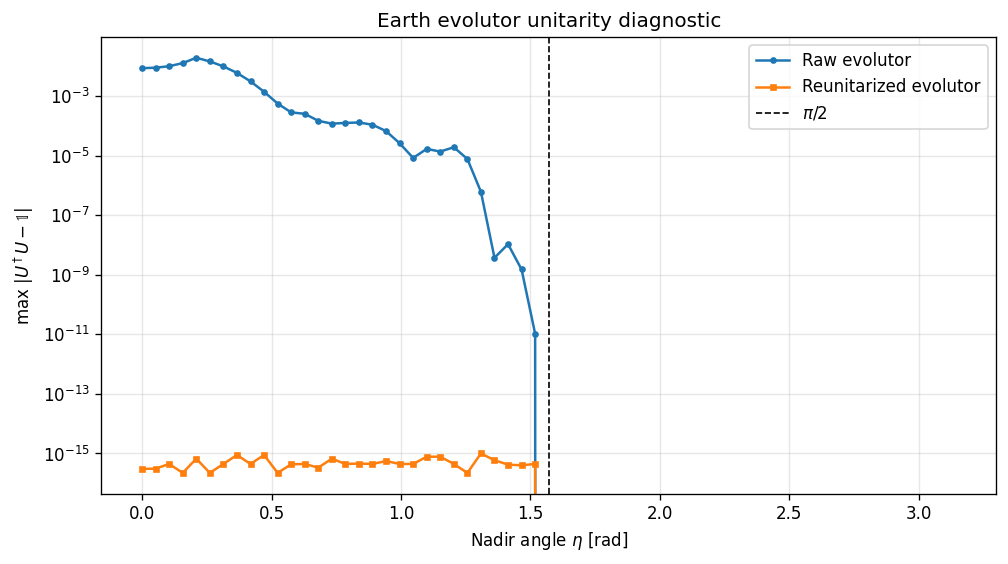

/mnt/v/output/diagnostic/earth/diagnostic2_fig3_unitarity_vs_eta.png
max raw unitarity error       : 1.964e-02
max reunitarized error        : 9.992e-16
reunitarize always <= raw     : True


In [4]:
eta_scan = torch.linspace(0.0, math.pi, 61, device=ctx.device, dtype=ctx.dtype)
E_fixed = torch.full_like(eta_scan, 2000.0)

U_raw = earth_evolutor(earth_profile, oscillation, E_fixed, eta_scan, DEPTH_SURFACE_M, reunitarize=False)
U_projected = earth_evolutor(earth_profile, oscillation, E_fixed, eta_scan, DEPTH_SURFACE_M, reunitarize=True)

raw_err = to_numpy(unitarity_error(U_raw))
projected_err = to_numpy(unitarity_error(U_projected))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.semilogy(to_numpy(eta_scan), raw_err, marker="o", ms=3, label="Raw evolutor")
ax.semilogy(to_numpy(eta_scan), projected_err, marker="s", ms=3, label="Reunitarized evolutor")
ax.axvline(math.pi / 2.0, color="black", ls="--", lw=1.0, label=r"$\pi/2$")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"max $|U^\dagger U - \mathbb{1}|$")
ax.set_title("Earth evolutor unitarity diagnostic")
ax.legend()

fig.tight_layout()
save_and_show("diagnostic2_fig3_unitarity_vs_eta.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"max raw unitarity error       : {float(np.max(raw_err)):.3e}")
print(f"max reunitarized error        : {float(np.max(projected_err)):.3e}")
print(f"reunitarize always <= raw     : {bool(np.all(projected_err <= raw_err + 1.0e-14))}")

## 4. Distance from Identity across Energy and Nadir Angle

$\|U-\mathbb{1}\|_F$ measures how far the evolution operator has moved from
trivial (no propagation) as a joint function of energy and nadir angle.

**Expected results:** the map should be exactly zero above the horizon
($\eta\ge\pi/2$ at the surface), and grow with both energy (faster oscillation
phase) and depth of Earth crossing (larger $|\eta-\pi/2|$ below the horizon,
up to the point where fast oscillations start to average out).

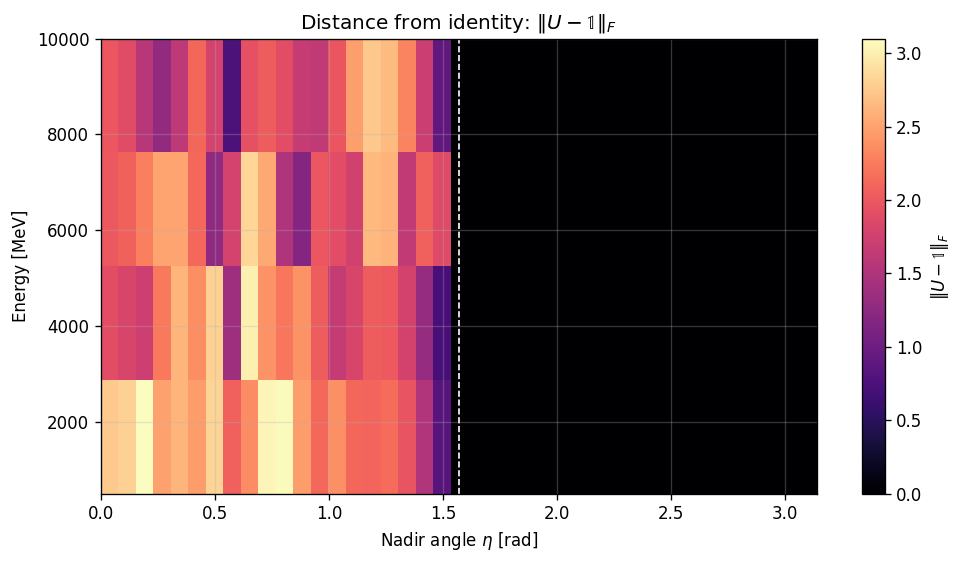

/mnt/v/output/diagnostic/earth/diagnostic2_fig4_distance_from_identity.png
max distance from identity: 3.1002
above-horizon column (eta=pi) max distance: 0.000e+00


In [5]:
E_map = torch.tensor([500.0, 1000.0, 3000.0, 10000.0], device=ctx.device, dtype=ctx.dtype)
eta_map = torch.linspace(0.0, math.pi, 41, device=ctx.device, dtype=ctx.dtype)

U_map = earth_evolutor(earth_profile, oscillation, E_map, eta_map, DEPTH_SURFACE_M, reunitarize=True)
dist_map = to_numpy(distance_from_identity(U_map))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
image = ax.imshow(
    dist_map,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[float(eta_map[0]), float(eta_map[-1]), float(E_map[0]), float(E_map[-1])],
    cmap="magma",
)
ax.axvline(math.pi / 2.0, color="white", ls="--", lw=1.0)
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel("Energy [MeV]")
ax.set_title(r"Distance from identity: $\|U-\mathbb{1}\|_F$")
fig.colorbar(image, ax=ax, label=r"$\|U-\mathbb{1}\|_F$")

fig.tight_layout()
save_and_show("diagnostic2_fig4_distance_from_identity.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"max distance from identity: {float(dist_map.max()):.4f}")
print(f"above-horizon column (eta=pi) max distance: {float(dist_map[:, -1].max()):.3e}")

## 5. Transition Probability Matrix Structure

Two representative trajectories, one Case A (through-Earth) and one Case B
(shallow underground), illustrate the structure of the evolution operator as a
transition probability matrix $|U_{\alpha\beta}|^2$: row $\alpha$ gives the
probability that a neutrino created in mass/flavour-mixed state $\beta$ is
found in row-basis state $\alpha$ after propagation. Unitarity guarantees each
row sums to exactly 1, so no ad hoc renormalization is applied (unlike the
historical backup script, which row-normalized $|U_{\alpha\beta}|$ directly).

**Expected results:** every row of both matrices should sum to 1; the Case B
(short, shallow path) matrix should sit closer to the identity than the Case A
(long, through-Earth path) matrix.

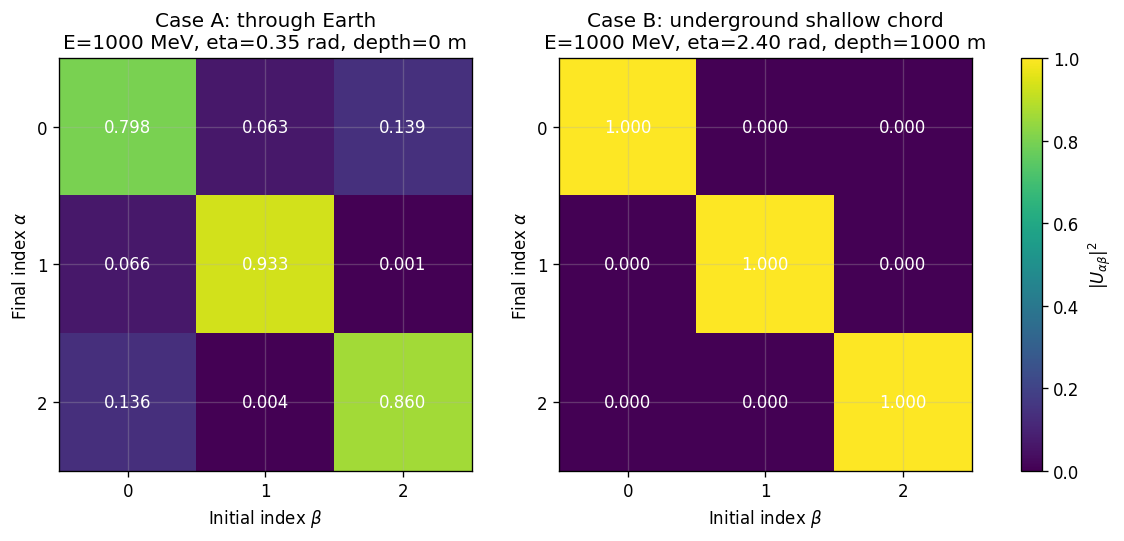

/mnt/v/output/diagnostic/earth/diagnostic2_fig5_transition_matrix.png
Case A: through Earth: row sums = [1. 1. 1.] (should all be 1.0)
Case B: underground shallow chord: row sums = [1. 1. 1.] (should all be 1.0)


In [6]:
case_configs = [
    ("Case A: through Earth", 1000.0, 0.35, DEPTH_SURFACE_M),
    ("Case B: underground shallow chord", 1000.0, 2.40, DEPTH_UNDERGROUND_M),
]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.4), constrained_layout=True)
matrices = []

for ax, (title, energy, eta_val, depth) in zip(axes, case_configs):
    U = earth_evolutor(
        earth_profile, oscillation,
        torch.tensor(energy, device=ctx.device, dtype=ctx.dtype),
        torch.tensor(eta_val, device=ctx.device, dtype=ctx.dtype),
        depth, reunitarize=True,
    )
    P_matrix = to_numpy(torch.abs(U) ** 2)
    matrices.append(P_matrix)

    image = ax.imshow(P_matrix, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_title(f"{title}\nE={energy:.0f} MeV, eta={eta_val:.2f} rad, depth={depth:.0f} m")
    ax.set_xlabel("Initial index $\\beta$")
    ax.set_ylabel("Final index $\\alpha$")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{P_matrix[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(image, ax=axes, label=r"$|U_{\alpha\beta}|^2$")
save_and_show("diagnostic2_fig5_transition_matrix.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

for (title, *_), P_matrix in zip(case_configs, matrices):
    row_sums = P_matrix.sum(axis=1)
    print(f"{title}: row sums = {row_sums} (should all be 1.0)")

## 6. Regeneration Probabilities for Pure Mass States

`earth_probability_state` in mass-basis mode is evaluated for each of the three pure mass
eigenstates ($w=(1,0,0)$, $(0,1,0)$, $(0,0,1)$) across the full nadir-angle
range.

**Expected results:** at $\eta\ge\pi/2$ (identity operator) each panel should
show the flat vacuum PMNS values $|U_{{\rm PMNS},\alpha i}|^2$; below the
horizon, matter effects reshuffle the flavour content, and every column of
probabilities should still sum to 1 at each $\eta$.

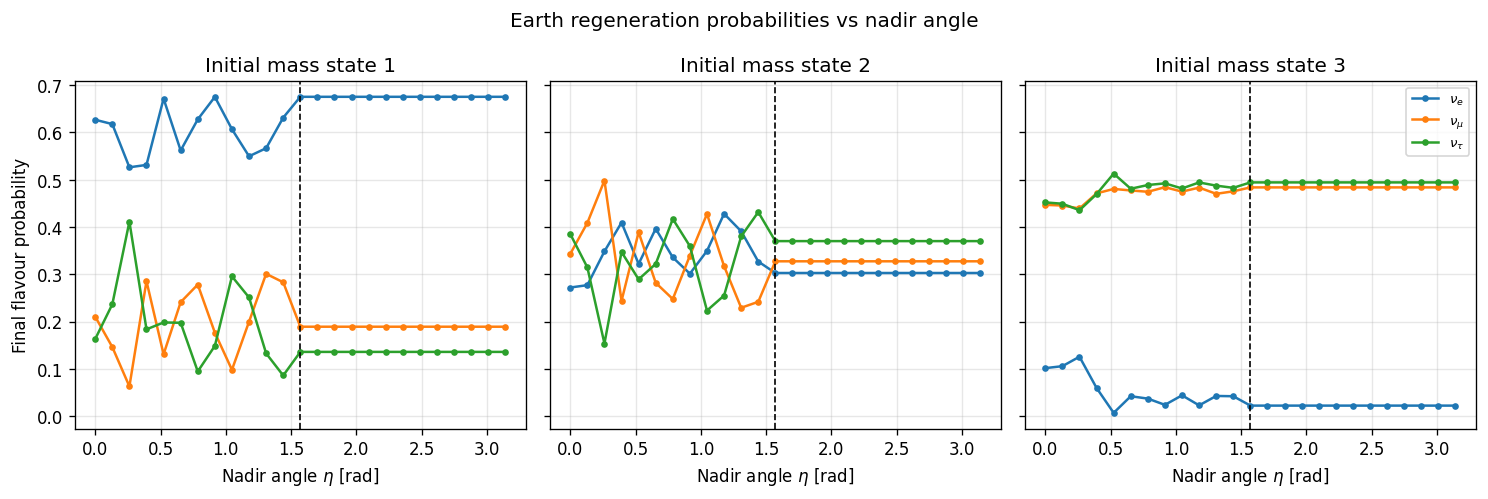

/mnt/v/output/diagnostic/earth/diagnostic2_fig6_probabilities_vs_eta_mass_states.png
max |sum_alpha P_alpha - 1| over all panels: 1.110e-15


In [7]:
eta_mass = torch.linspace(0.0, math.pi, 25, device=ctx.device, dtype=ctx.dtype)
E_mass = torch.full_like(eta_mass, 2000.0)

mass_states = [
    ("Initial mass state 1", torch.tensor([1.0, 0.0, 0.0], device=ctx.device, dtype=ctx.dtype)),
    ("Initial mass state 2", torch.tensor([0.0, 1.0, 0.0], device=ctx.device, dtype=ctx.dtype)),
    ("Initial mass state 3", torch.tensor([0.0, 0.0, 1.0], device=ctx.device, dtype=ctx.dtype)),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharey=True)
max_row_sum_err = 0.0

for ax, (title, weights) in zip(axes, mass_states):
    P = earth_probability_state(weights, earth_profile, oscillation, E_mass, eta_mass, DEPTH_SURFACE_M,
               method="analytical", massbasis=True, reunitarize=True)
    max_row_sum_err = max(max_row_sum_err, float(torch.max(torch.abs(P.sum(dim=-1) - 1.0))))

    for idx, label in enumerate(FLAVOUR_LABELS):
        ax.plot(to_numpy(eta_mass), to_numpy(P[:, idx]), marker="o", ms=3, label=label)
    ax.axvline(math.pi / 2.0, color="black", ls="--", lw=1.0)
    ax.set_title(title)
    ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Final flavour probability")
axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("Earth regeneration probabilities vs nadir angle")
fig.tight_layout()

save_and_show("diagnostic2_fig6_probabilities_vs_eta_mass_states.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
print(f"max |sum_alpha P_alpha - 1| over all panels: {max_row_sum_err:.3e}")

## 7. Electron-Flavour Probability Map

The electron-flavour regeneration probability $P_e(E,\eta)$ for a fixed mass
composition, mapped jointly over energy and nadir angle.

**Expected results:** $P_e$ should be exactly flat above the horizon and show
energy-dependent oscillatory structure below it, consistent with the
distance-from-identity map of Section 4.

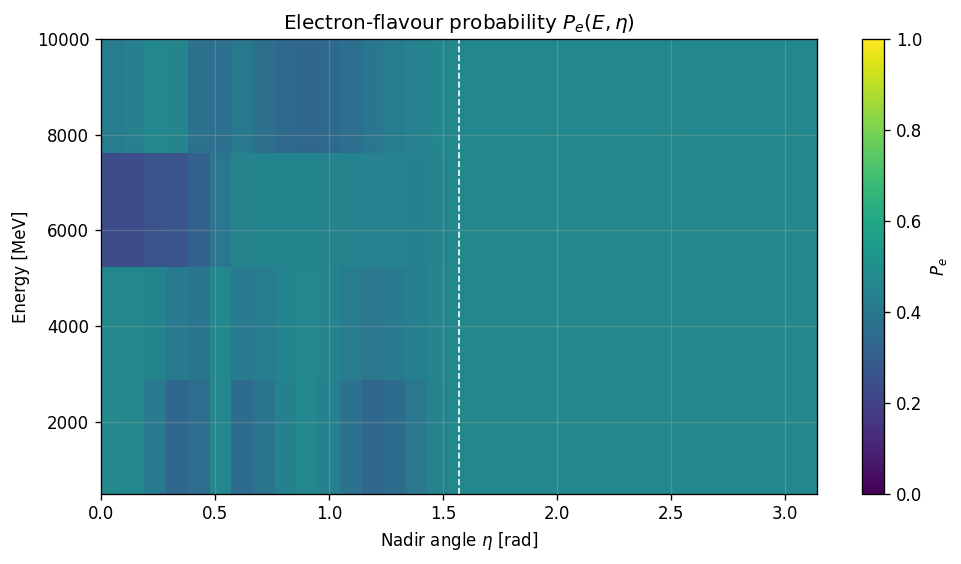

/mnt/v/output/diagnostic/earth/diagnostic2_fig7_probability_energy_eta_map.png


In [8]:
weights_map = torch.tensor([0.55, 0.30, 0.15], device=ctx.device, dtype=ctx.dtype)
E_pmap = torch.tensor([500.0, 1000.0, 3000.0, 10000.0], device=ctx.device, dtype=ctx.dtype)
eta_pmap = torch.linspace(0.0, math.pi, 33, device=ctx.device, dtype=ctx.dtype)

P_map = earth_probability_state(weights_map, earth_profile, oscillation, E_pmap, eta_pmap, DEPTH_SURFACE_M,
               method="analytical", massbasis=True, reunitarize=True)
P_e_map = to_numpy(P_map[..., 0])

fig, ax = plt.subplots(figsize=(8.5, 4.8))
image = ax.imshow(
    P_e_map,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[float(eta_pmap[0]), float(eta_pmap[-1]), float(E_pmap[0]), float(E_pmap[-1])],
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
ax.axvline(math.pi / 2.0, color="white", ls="--", lw=1.0)
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel("Energy [MeV]")
ax.set_title(r"Electron-flavour probability $P_e(E,\eta)$")
fig.colorbar(image, ax=ax, label=r"$P_e$")

fig.tight_layout()
save_and_show("diagnostic2_fig7_probability_energy_eta_map.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 8. Mass-Basis versus Flavour-Basis Input

The same electron-flavour probability computed from a pure mass-eigenstate-1
input (mass basis) and from a pure electron-flavour input (flavour basis),
across the nadir-angle range.

**Expected results:** the two curves generally differ (different physical
inputs), but both should equal exactly 1 above the horizon only for the
flavour-basis curve (identity preserves flavour), while the mass-basis curve
flattens to the vacuum value $|U_{{\rm PMNS},e1}|^2$ instead.

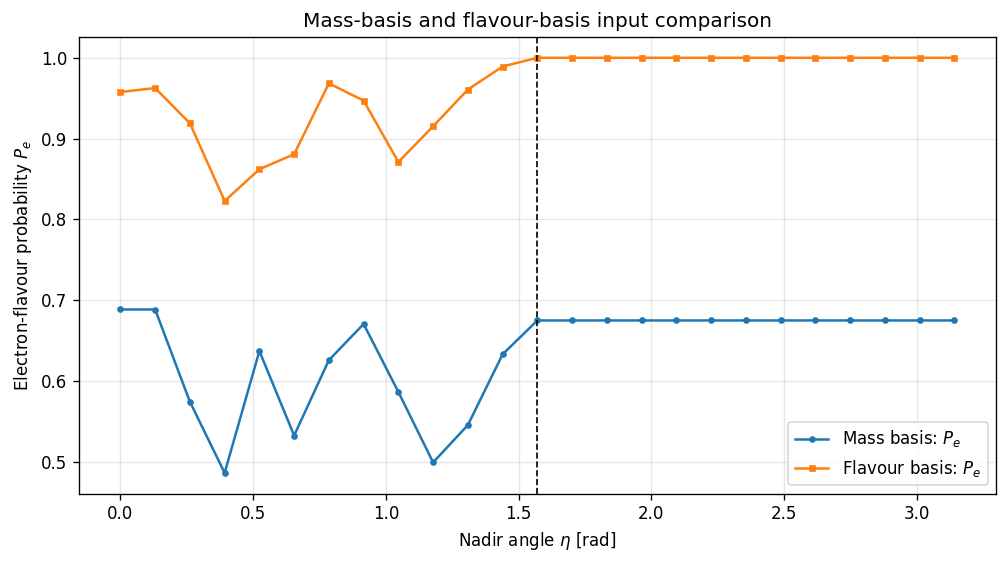

/mnt/v/output/diagnostic/earth/diagnostic2_fig8_mass_vs_flavour_basis.png
Above-horizon mass-basis P_e   : 0.675043 (expected |U_e1|^2 = 0.675043)
Above-horizon flavour-basis P_e: 1.000000 (expected 1.0)


In [9]:
eta_cmp = torch.linspace(0.0, math.pi, 25, device=ctx.device, dtype=ctx.dtype)
E_cmp = torch.full_like(eta_cmp, 1500.0)

mass_weights = torch.tensor([1.0, 0.0, 0.0], device=ctx.device, dtype=ctx.dtype)
flavour_e = torch.tensor([1.0, 0.0, 0.0], device=ctx.device, dtype=torch.complex128)

P_mass = earth_probability_state(mass_weights, earth_profile, oscillation, E_cmp, eta_cmp, DEPTH_SURFACE_M,
                 method="analytical", massbasis=True, reunitarize=True)
P_flavour = earth_probability_state(flavour_e, earth_profile, oscillation, E_cmp, eta_cmp, DEPTH_SURFACE_M,
                    method="analytical", massbasis=False, reunitarize=True)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(to_numpy(eta_cmp), to_numpy(P_mass[:, 0]), marker="o", ms=3, label=r"Mass basis: $P_e$")
ax.plot(to_numpy(eta_cmp), to_numpy(P_flavour[:, 0]), marker="s", ms=3, label=r"Flavour basis: $P_e$")
ax.axvline(math.pi / 2.0, color="black", ls="--", lw=1.0)
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"Electron-flavour probability $P_e$")
ax.set_title("Mass-basis and flavour-basis input comparison")
ax.legend()

fig.tight_layout()
save_and_show("diagnostic2_fig8_mass_vs_flavour_basis.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

vacuum_e1 = float(torch.abs(oscillation.pmns.pmns_matrix()[0, 0]) ** 2)
print(f"Above-horizon mass-basis P_e   : {float(P_mass[-1, 0]):.6f} (expected |U_e1|^2 = {vacuum_e1:.6f})")
print(f"Above-horizon flavour-basis P_e: {float(P_flavour[-1, 0]):.6f} (expected 1.0)")

## 9. Analytical versus Numerical Agreement

Both `earth_probability_state` methods are compared in flavour basis, where they act on the same
coherent input state: a Case A (through-Earth) trajectory and a Case B
(shallow underground) trajectory, plus the error trend as $\eta$ sweeps through
the Case A region.

**Expected results:** Case A agreement at the $10^{-3}$ level (perturbative
truncation of the analytical path), Case B agreement close to machine precision
(a single constant-density segment, exactly representable by both methods).

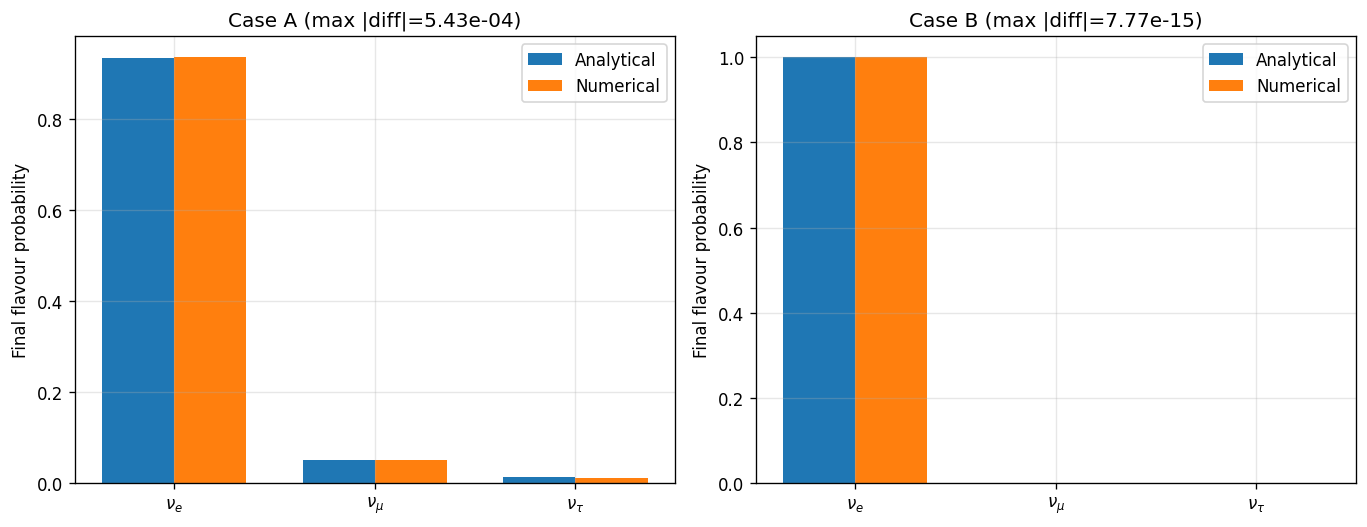

/mnt/v/output/diagnostic/earth/diagnostic2_fig9a_analytical_vs_numerical_bars.png


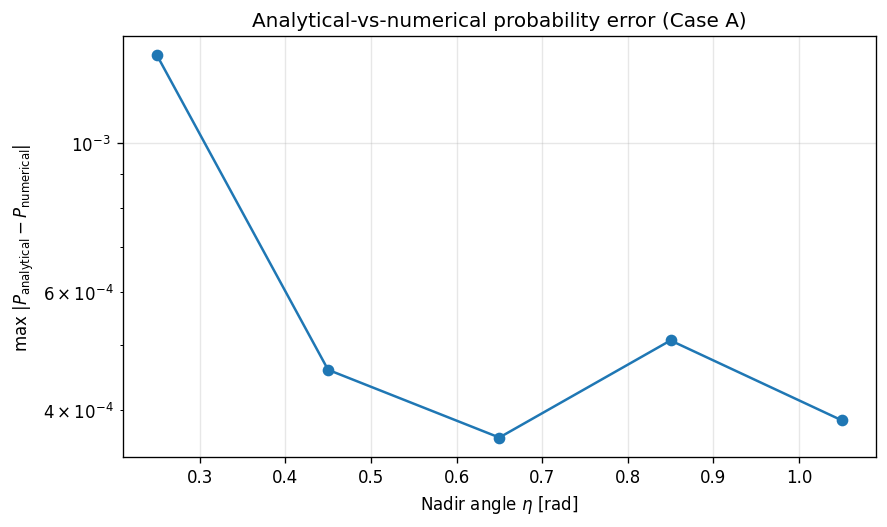

/mnt/v/output/diagnostic/earth/diagnostic2_fig9b_error_vs_eta.png
Case A max |diff| : 5.435e-04  (pytest tolerance: 5e-3)
Case B max |diff| : 7.772e-15  (pytest tolerance: 5e-6)


In [10]:
NSTEPS_COMPARE = 200
psi_e = torch.tensor([1.0, 0.0, 0.0], device=ctx.device, dtype=torch.complex128)

def analytical_flavour(E, eta_val, depth_m):
    return earth_probability_state(psi_e, earth_profile, oscillation, E, eta_val, depth_m,
                  method="analytical", massbasis=False, reunitarize=True)

def numerical_flavour(E, eta_val, depth_m, nsteps=NSTEPS_COMPARE, full_oscillation=False):
    return earth_probability_state(psi_e, earth_profile, oscillation, E, eta_val, depth_m,
                  method="numerical", massbasis=False, full_oscillation=full_oscillation,
                  nsteps=nsteps, ode_method="midpoint", context=ctx)

E_fixed_cmp = torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype)
case_a_eta = torch.tensor(0.60, device=ctx.device, dtype=ctx.dtype)
case_b_eta = torch.tensor(2.40, device=ctx.device, dtype=ctx.dtype)

P_a_analytical = analytical_flavour(E_fixed_cmp, case_a_eta, DEPTH_SURFACE_M)
P_a_numerical = numerical_flavour(E_fixed_cmp, case_a_eta, DEPTH_SURFACE_M)
P_b_analytical = analytical_flavour(E_fixed_cmp, case_b_eta, DEPTH_UNDERGROUND_M)
P_b_numerical = numerical_flavour(E_fixed_cmp, case_b_eta, DEPTH_UNDERGROUND_M)

err_a = float(torch.max(torch.abs(P_a_analytical - P_a_numerical)))
err_b = float(torch.max(torch.abs(P_b_analytical - P_b_numerical)))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
x_idx = np.arange(3)
width = 0.36

for ax, title, P_an, P_num, err in [
    (axes[0], f"Case A (max |diff|={err_a:.2e})", P_a_analytical, P_a_numerical, err_a),
    (axes[1], f"Case B (max |diff|={err_b:.2e})", P_b_analytical, P_b_numerical, err_b),
]:
    ax.bar(x_idx - width / 2.0, to_numpy(P_an), width=width, label="Analytical")
    ax.bar(x_idx + width / 2.0, to_numpy(P_num), width=width, label="Numerical")
    ax.set_xticks(x_idx)
    ax.set_xticklabels(FLAVOUR_LABELS)
    ax.set_ylabel("Final flavour probability")
    ax.set_title(title)
    ax.legend()

fig.tight_layout()
save_and_show("diagnostic2_fig9a_analytical_vs_numerical_bars.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

eta_err_scan = torch.tensor([0.25, 0.45, 0.65, 0.85, 1.05], device=ctx.device, dtype=ctx.dtype)
errors = []
for eta_val in eta_err_scan:
    P_an = analytical_flavour(E_fixed_cmp, eta_val, DEPTH_SURFACE_M)
    P_num = numerical_flavour(E_fixed_cmp, eta_val, DEPTH_SURFACE_M, nsteps=60)
    errors.append(float(torch.max(torch.abs(P_an - P_num))))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogy(to_numpy(eta_err_scan), errors, marker="o")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"max $|P_{\rm analytical}-P_{\rm numerical}|$")
ax.set_title("Analytical-vs-numerical probability error (Case A)")

fig.tight_layout()
save_and_show("diagnostic2_fig9b_error_vs_eta.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"Case A max |diff| : {err_a:.3e}  (pytest tolerance: 5e-3)")
print(f"Case B max |diff| : {err_b:.3e}  (pytest tolerance: 5e-6)")

## 10. Numerical Path Evolution

The numerical method can return the full probability history along the sampled
trajectory (`full_oscillation=True`), which uses the sequential $O(N)$
composition path (Section 0.4) since the intermediate states are needed. This
is compared against the analytical final-point reference.

**Expected results:** the numerical curves should approach the analytical
dashed reference lines by the end of the trajectory ($x=x_d$); the mid-path
oscillatory structure has no analytical counterpart since the perturbative
method only returns the final state.

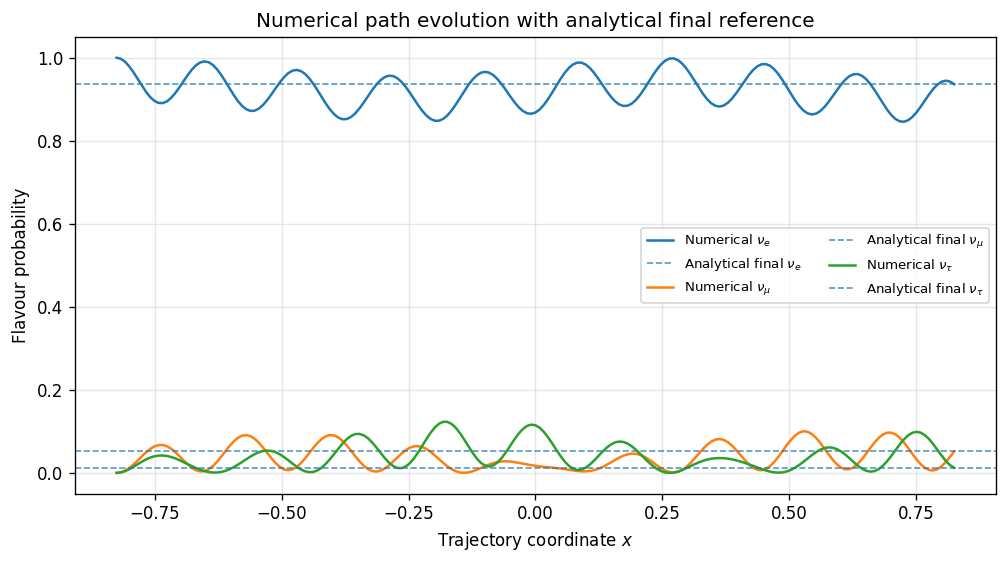

/mnt/v/output/diagnostic/earth/diagnostic2_fig10_numerical_path_evolution.png
evolution shape          : (201, 3)
final numerical vs analytical max |diff|: 5.435e-04


In [11]:
evolution, x_path = numerical_flavour(E_fixed_cmp, case_a_eta, DEPTH_SURFACE_M, full_oscillation=True)
P_analytical_ref = analytical_flavour(E_fixed_cmp, case_a_eta, DEPTH_SURFACE_M)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for idx, label in enumerate(FLAVOUR_LABELS):
    ax.plot(to_numpy(x_path), to_numpy(evolution[:, idx]), label=f"Numerical {label}")
    ax.axhline(float(P_analytical_ref[idx]), ls="--", lw=1.0, alpha=0.75, label=f"Analytical final {label}")

ax.set_xlabel("Trajectory coordinate $x$")
ax.set_ylabel("Flavour probability")
ax.set_title("Numerical path evolution with analytical final reference")
ax.legend(ncol=2, fontsize=8)

fig.tight_layout()
save_and_show("diagnostic2_fig10_numerical_path_evolution.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

final_diff = float(torch.max(torch.abs(evolution[-1] - P_analytical_ref)))
print(f"evolution shape          : {tuple(evolution.shape)}")
print(f"final numerical vs analytical max |diff|: {final_diff:.3e}")

## 11. Summary

In [12]:
print("Summary - Earth Diagnostic 2: Matter Evolution and Regeneration Probabilities")
print("-" * 70)
print(f"Loaded Earth model              : {earth_profile}")
print(f"max raw unitarity error         : {float(np.max(raw_err)):.3e}")
print(f"max reunitarized unitarity error: {float(np.max(projected_err)):.3e}")
print(f"max |sum P - 1| (mass states)   : {max_row_sum_err:.3e}")
print(f"Case A analytical-vs-numerical  : {err_a:.3e} (tol 5e-3)")
print(f"Case B analytical-vs-numerical  : {err_b:.3e} (tol 5e-6)")
print(f"numerical full-path final match : {final_diff:.3e}")
print()
print("Pytest companions: tpeanuts.medium.earth.test.test3_evolutor, tpeanuts.medium.earth.test.test4_probabilities")
print("Density/geometry companion: notebooks/diagnostic/earth/diagnostic1_earth_density.ipynb")

Summary - Earth Diagnostic 2: Matter Evolution and Regeneration Probabilities
----------------------------------------------------------------------
Loaded Earth model              : EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64
max raw unitarity error         : 1.964e-02
max reunitarized unitarity error: 9.992e-16
max |sum P - 1| (mass states)   : 1.110e-15
Case A analytical-vs-numerical  : 5.435e-04 (tol 5e-3)
Case B analytical-vs-numerical  : 7.772e-15 (tol 5e-6)
numerical full-path final match : 5.435e-04

Pytest companions: tpeanuts.medium.earth.test.test3_evolutor, tpeanuts.medium.earth.test.test4_probabilities
Density/geometry companion: notebooks/diagnostic/earth/diagnostic1_earth_density.ipynb
